In [1]:
import os
print(os.getcwd())
cwd = os.getcwd()
os.chdir('../../')
import rsnapsim as rsnp  # import the rsnapsim
os.chdir(cwd)


C:\Users\wsraymon\GitHub\rSNAPsim\rsnapsim\interactive_notebooks
[]



In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# load a sequence file
# When we load a sequence file, several objects are returned:

# aaseq_dict - a dictionary of detected orfs reported as their amino acid sequences, keyed by frame
# cds_dict - a dictionary of detected orfs converted to CDS objects keyed by frame
# tagged_cdss - a dictionary of detected orfs with known fluorescent epitopes
# source_seq - a single string of the raw sequence pulled from the file

aaseq_dict, cds_dict, tagged_cdss, source_seq = rsnp.seqmanip.open_seq_file('../gene_files/NC_005816.gb', add_tag=False)

In [4]:
cds_dict

{'0': [<rsnapsim.cds.CDS at 0x1763c9ee7a0>],
 '+1': [<rsnapsim.cds.CDS at 0x1763c9ee4a0>,
 '+2': [<rsnapsim.cds.CDS at 0x1763c9ee8c0>,
 '-1': [<rsnapsim.cds.CDS at 0x1763c9eea10>,
  <rsnapsim.cds.CDS at 0x1763c9eeb30>]}

In [5]:
# Lets look at how many valid coding regions were detected: 
cds_count = [len(cds_dict[x]) for x in ['0','+1','-1']]
print('cds count in the  %s frame: %i'%('0',cds_count[0]))
print('cds count in the %s frame: %i'%('+1',cds_count[1]))
print('cds count in the %s frame: %i'%('-1',cds_count[2]))


cds count in the  0 frame: 1
cds count in the +1 frame: 3
cds count in the -1 frame: 4


In [6]:
# lets take a look at what a CDS object contains
cds_dict['0'][0].__dict__

{'aa_seq': 'MKKSSIVATIITILSGSANAASSQLIPNISPDSFTVAASTGMLSGKSHEMLYDAETGRKISQLDWKIKNVAILKGDISWDPYSFLTLNARGWTSLASGSGNMDDYDWMNENQSEWTDHSSHPATNVNHANEYDLNVKGWLLQDENYKAGITAGYQETRFSWTATGGSYSYNNGAYTGNFPKGVRVIGYNQRFSMPYIGLAGQYRINDFELNALFKFSDWVRAHDNDEHYMRDLTFREKTSGSRYYGTVINAGYYVTPNAKVFAEFTYSKYDEGKGGTQIIDKNSGDSVSIGGDAAGISNKNYTVTAGLQYRF*',
 'nt_seq': 'AUGAAGAAAAGUUCUAUUGUGGCAACCAUUAUAACUAUUCUGUCCGGGAGUGCUAAUGCAGCAUCAUCUCAGUUAAUACCAAAUAUAUCCCCUGACAGCUUUACAGUUGCAGCCUCCACCGGGAUGCUGAGUGGAAAGUCUCAUGAAAUGCUUUAUGACGCAGAAACAGGAAGAAAGAUCAGCCAGUUAGACUGGAAGAUCAAAAAUGUCGCUAUCCUGAAAGGUGAUAUAUCCUGGGAUCCAUACUCAUUUCUGACCCUGAAUGCCAGGGGGUGGACGUCUCUGGCUUCCGGGUCAGGUAAUAUGGAUGACUACGACUGGAUGAAUGAAAAUCAAUCUGAGUGGACAGAUCACUCAUCUCAUCCUGCUACAAAUGUUAAUCAUGCCAAUGAAUAUGACCUCAAUGUGAAAGGCUGGUUACUCCAGGAUGAGAAUUAUAAAGCAGGUAUAACAGCAGGAUAUCAGGAAACACGUUUCAGUUGGACAGCUACAGGUGGUUCAUAUAGUUAUAAUAAUGGAGCUUAUACCGGAAACUUCCCGAAAGGAGUGCGGGUAAUAGGUUAUAACCAGCGCUUUUCUAUGCCAUAUAUUGGACUUGCAGGCCAGUAUCGCAUUAAUGAUUUUGAGUUAAAUGCAUUAUUUAAAUUCAGCGACUGGGUU

In [7]:
# how large is each open reading frame?
[[len(x.aa_seq) for x in cds_dict[y]] for y in ['0','+1','-1']]

[[313], [260, 146, 139], [341, 89, 81, 93]]

In [8]:
# lets simulate translation on the largest coding region. 
largest_CDS = cds_dict['+1'][0]

In [9]:
largest_CDS.aa_seq

'MMELQHQRLMALAGQLQLESLISAAPALSQQAVDQEWSYMDFLEHLLHEEKLARHQRKQAMYTRMAAFPAVKTFEEYDFTFATGAPQKQLQSLRSLSFIERNENIVLLGPSGVGKTHLAIAMGYEAVRAGIKVRFTTAADLLLQLSTAQRQGRYKTTLQRGVMAPRLLIIDEIGYLPFSQEEAKLFFQVIAKRYEKSAMILTSNLPFGQWDQTFAGDAALTSAMLDRILHHSHVVQIKGESYRLRQKRKAGVIAEANPE*'

So this protein is from yersinia pestis (plague) you can see the original NCBI genbank file here: https://www.ncbi.nlm.nih.gov/nuccore/NC_005816

In [10]:
# how do we solve a model?
rsnp.solver.solve_ssa?

Signature:
rsnp.solver.solve_ssa(
    mRNA_model,
    t,
    n_traj=1,
    burnin=0,
    seed=None,
    parallel=False,
    cplus=False,
    cores=4,
    probe_list=None,
    ki=None,
    kt=None,
)
Docstring: <no docstring>
File:      c:\users\wsraymon\github\rsnapsim\rsnapsim\solver.py
Type:      method

In [11]:
#currently you can pass a CDS directly to the model solver, this is ambigious and needs to change!!
t = np.linspace(0,1000,10001)
soln = rsnp.solver.solve_ssa(largest_CDS, t)

In [12]:
soln.lattice_arr.shape # ribosomal movement array N_traj x time x max_ribosomes

(1, 10001, 260)

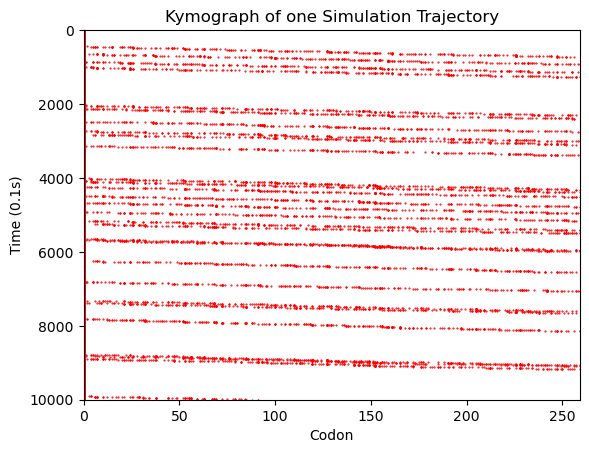

In [13]:
fig,ax = plt.subplots(1,1)
c = ax.plot(soln.ribosome_array[0][:,:,6] ,'r.',markersize=1)
newx = [x.get_xdata() for x in c]
newy =  [x.get_ydata() for x in c]
[c[x].set_xdata(newy[x]) for x in range(len(c))]
[c[x].set_ydata(newx[x]) for x in range(len(c))]
ax.set_title('Kymograph of one Simulation Trajectory')
ax.set_xlabel('Codon')
ax.set_ylabel('Time (0.1s)')
ax.set_xlim([0,max(newy[0])])
ax.set_ylim([0,max(newx[0])])
ax.invert_yaxis()

In [14]:
#currently you can pass a CDS directly, or a list of stepping rates to the model solver, this is ambigious and needs to change!!
# Manually induce a pause!
k = largest_CDS.kelong
k[100] = .1
t = np.linspace(0,1000,10001)
soln = rsnp.solver.solve_ssa(k, t, probe_list = [], ki = .03, kt=10)

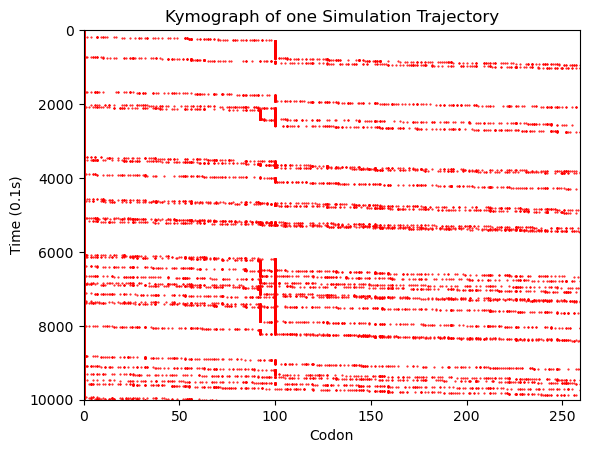

In [15]:
fig,ax = plt.subplots(1,1)
c = ax.plot(soln.ribosome_array[0][:,:,6] ,'r.',markersize=1)
newx = [x.get_xdata() for x in c]
newy =  [x.get_ydata() for x in c]
[c[x].set_xdata(newy[x]) for x in range(len(c))]
[c[x].set_ydata(newx[x]) for x in range(len(c))]
ax.set_title('Kymograph of one Simulation Trajectory')
ax.set_xlabel('Codon')
ax.set_ylabel('Time (0.1s)')
ax.set_xlim([0,max(newy[0])])
ax.set_ylim([0,max(newx[0])])
ax.invert_yaxis()

In [16]:
soln.intensity_arr.sum() #hang on theres no intensity? Yes because we didn't tag it with any fluorescent epitopes!

0

In [17]:
rsnp.cdict.tag_dict # Here are some of our tagging options

{'T_SunTag': 'EELLSKNYHLENEVARLKK',
 'T_Flag': 'DYKDDDDK',
 'T_Hemagglutinin': 'YPYDVPDYA',
 'T_Myc': 'EQKLISEEDL',
 'T_Strep': 'WSHPQFEK',
 'T_Hist': 'HHHHHH',
 'T_V5': 'GKPIPNPLLGLDST',
 'T_TC': 'CCPGCC'}

In [18]:
rsnp.cdict.tag_full['T_Flag'] #lets add a full 10x tflag

'ATGGACTACAAGGACGACGACGACAAAGGTGACTACAAAGATGATGACGATAAAGGCGACTATAAGGACGATGACGACAAGGGCGGAAACTCACTGATCAAGGAAAACATGCGGATGAAGGTGGTGATGGAGGGCTCCGTGAATGGTCACCAGTTCAAGTGCACCGGAGAGGGAGAGGGAAACCCGTACATGGGAACTCAGACCATGCGCATTAAGGTCATCGAAGGAGGTCCGCTGCCGTTCGCTTTCGATATCCTGGCCACTTCGTTCGGAGGAGGGTCGCGCACGTTCATCAAGTACCCGAAGGGAATCCCGGACTTCTTTAAGCAGTCATTCCCGGAAGGATTCACTTGGGAACGGGTGACCCGGTATGAAGATGGAGGTGTGGTGACTGTCATGCAAGATACTTCGCTGGAGGATGGGTGCCTCGTGTACCACGTCCAAGTCCGCGGAGTGAATTTCCCGTCCAACGGACCAGTGATGCAGAAAAAGACGAAGGGTTGGGAACCTAATACTGAAATGATGTACCCCGCAGACGGAGGGCTGAGGGGCTACACCCACATGGCGCTGAAGGTCGACGGAGGAGATTACAAGGATGACGACGATAAGCAACAAGATTACAAAGACGATGATGACAAGGGCCAGCAGGGCGACTACAAGGACGACGACGACAAGCAGCAGGACTACAAAGATGACGATGATAAAGGAGGAGGACATCTGTCCTGTTCGTTCGTGACCACCTACAGATCAAAGAAAACCGTGGGAAACATCAAGATGCCGGGCATTCATGCCGTCGACCACCGCCTGGAGCGGCTCGAAGAATCAGACAATGAGATGTTCGTCGTGCAAAGAGAACATGCCGTGGCCAAGTTCGCGGGACTGGGAGGCGGTGGAGGCGATTACAAAGACGATGATGACAAGGGTGACTATAAAGACGACGATGACAAAGGGGATTACAAGGATGATGATGATAAGGGAGGCGGTGGATCAGGTGGAGGA

In [19]:
newseq = rsnp.cdict.tag_full['T_Flag'] + largest_CDS.nt_seq
tagged_CDS = rsnp.seqmanip.seq_to_CDS_obj(newseq)['0'][0] 
tagged_CDS.generate_3frame_tags()

In [20]:
t = np.linspace(0,1000,10001)
soln = rsnp.solver.solve_ssa(tagged_CDS, t)

In [22]:
soln.intensity_arr.sum() #now we should have intensity

90899

Text(0, 0.5, 'Intensity (# probes)')

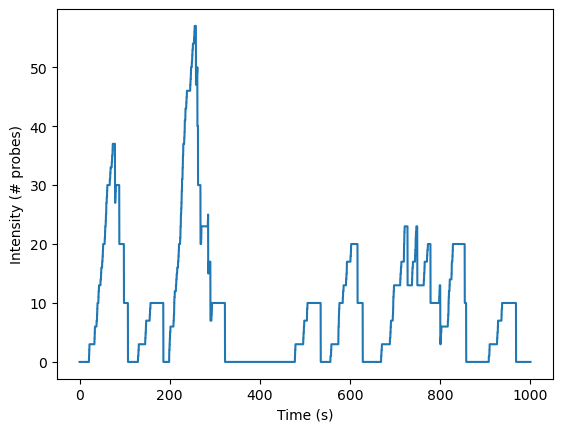

In [26]:
plt.plot(soln.t, soln.intensity_arr[0])
plt.xlabel('Time (s)')
plt.ylabel('Intensity (# probes)')